In [81]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

rng = np.random.default_rng(30)

Part 1

In [82]:
rng = np.random.default_rng(30)

n = 100
U = [rng.uniform(0,1) for _ in range (n)]
X = np.exp(U)
theta = np.mean(X)
print("Point estimate =", theta)

S = np.std(X, ddof=1)
lower = theta - 2 * S / np.sqrt(n)
upper = theta + 2 * S / np.sqrt(n)
print("95% confidence interval = (", lower, ",", upper, ")")

Point estimate = 1.7207379667184908
95% confidence interval = ( 1.6249874037720842 , 1.8164885296648974 )


Part 2

In [83]:
rng = np.random.default_rng(30)

n = 100
U = [rng.uniform(0,1) for _ in range (n)]
Uant = [1-U[i] for i in range(n)]
Y = (np.exp(U) + np.exp(Uant)) / 2
theta = np.mean(Y)
print("Point estimate =", theta)

S = np.std(Y, ddof=1)
lower = theta - 2 * S / np.sqrt(n)
upper = theta + 2 * S / np.sqrt(n)
print("95% confidence interval = (", lower, ",", upper, ")")

Point estimate = 1.7079341193220712
95% confidence interval = ( 1.6960067136619288 , 1.7198615249822136 )


Part 3

In [84]:
rng = np.random.default_rng(30)

n = 100
X = np.exp([rng.uniform(0,1) for _ in range (n)])
Z = [rng.uniform(0,1) for _ in range (n)]
muZ = np.mean(Z)
c = - np.cov(X,Z,ddof=1)[0,1] / np.var(Z,ddof=1)
Y = X + c * (Z - muZ)
theta = np.mean(Y)
print("Point estimate =", theta)

S = np.std(Y, ddof=1)
lower = theta - 2 * S / np.sqrt(n)
upper = theta + 2 * S / np.sqrt(n)
print("95% confidence interval = (", lower, ",", upper, ")")

Point estimate = 1.7207379667184908
95% confidence interval = ( 1.62522359116903 , 1.8162523422679515 )


Part 4

In [85]:
rng = np.random.default_rng(30)

n = 100
U = [rng.uniform(i/n, (i+1)/n) for i in range(n)]
Y = np.exp(U)
theta = np.mean(Y)
print("Point estimate =", theta)

S = np.std(Y, ddof=1)
lower = theta - 2 * S / np.sqrt(n)
upper = theta + 2 * S / np.sqrt(n)
print("95% confidence interval = (", lower, ",", upper, ")")

Point estimate = 1.7184173298576102
95% confidence interval = ( 1.6195169078773806 , 1.8173177518378398 )


Part 5

In [86]:
def poisson_blocking_system(m, s, lbd, max, rng):

    t = 0
    t_serv = np.zeros(m)
    arrivals = 0
    blocked = 0
    inter = []

    while arrivals < max:

        arrivals += 1
        t_arr = rng.exponential(lbd)
        inter.append(t_arr)
        t += t_arr
        t_serv -= t_arr
        t_serv = np.clip(t_serv, 0, None)

        mask = t_serv == 0
        if np.sum(mask) == 0:
            blocked += 1
        else:
            for i in range(m):
                if t_serv[i] == 0:
                    t_serv[i] = rng.exponential(s)
                    break

    frac_blocked = blocked/max
    Z = np.mean(inter)

    return frac_blocked, Z

In [96]:
rng = np.random.default_rng(30)

n = 10

X = np.zeros(n)
Z = np.zeros(n)
for i in range(n):
    X[i], Z[i] = poisson_blocking_system(10, 8, 1, 10000, rng)

muZ = np.mean(Z)
print(muZ)
c = - np.cov(X,Z,ddof=1)[0,1] / np.var(Z,ddof=1)
Y = X + c * (Z - muZ)
theta = np.mean(Y)
print("Point estimate =", theta)

S = np.std(Y, ddof=1)
lower = theta - 2 * S / np.sqrt(n)
upper = theta + 2 * S / np.sqrt(n)
print("95% confidence interval = (", lower, ",", upper, ")")

0.9996968787587258
Point estimate = 0.12253999999999994
95% confidence interval = ( 0.11972774645977183 , 0.12535225354022805 )


Part 6

Part 7

In [88]:
rng = np.random.default_rng(30)

Z = np.array([rng.normal(0,1) for _ in range(n)])
a = 2
greater = (Z > a)
proba = np.mean(greater)
print('The probability of Z being greater than a is', proba, 'for a =', a)

The probability of Z being greater than a is 0.1 for a = 2


In [89]:
def importance_sampling(a, sig2, n, rng):

    sigma = np.sqrt(sig2)
    Y = rng.normal(loc=a, scale=sigma, size=n)

    f = norm.pdf(Y, 0, 1)
    g = norm.pdf(Y, a, sigma)

    h = (Y > a)
    theta_hat = np.mean(h * (f / g))

    return theta_hat

For a = 2
For n = 1000 iterations, the probability is 0.024104225528554457
For n = 10000 iterations, the probability is 0.022843059930362345
For n = 100000 iterations, the probability is 0.022556397709203164
For n = 1000000 iterations, the probability is 0.02281808451922828
For n = 10000000 iterations, the probability is 0.02278249488575857


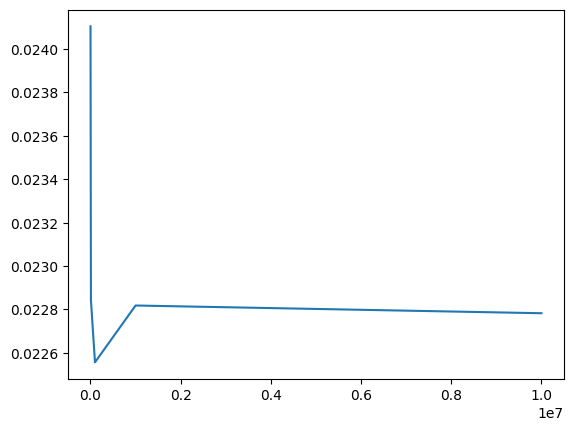

In [90]:
rng = np.random.default_rng(30)

print('For a =', 2)
proba = []
N = [1000, 10000, 100000, 1000000, 10000000]
for n in N:
    p = importance_sampling(2, 1, n, rng)
    print('For n =', n, 'iterations, the probability is', p)
    proba.append(p)
plt.plot(N, proba)

For a = 4
For n = 1000 iterations, the probability is 0.024104225528554457
For n = 10000 iterations, the probability is 0.022843059930362345
For n = 100000 iterations, the probability is 0.022556397709203164
For n = 1000000 iterations, the probability is 0.02281808451922828
For n = 10000000 iterations, the probability is 0.02278249488575857


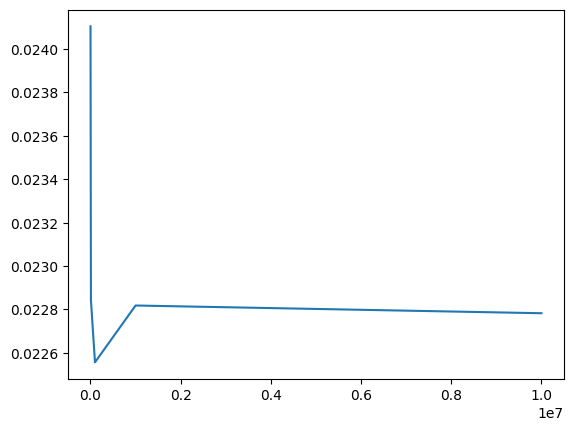

In [91]:
rng = np.random.default_rng(30)

print('For a =', 4)
proba = []
N = [1000, 10000, 100000, 1000000, 10000000]
for n in N:
    p = importance_sampling(a, 1, n, rng)
    print('For n =', n, 'iterations, the probability is', p)
    proba.append(p)
plt.plot(N, proba)

For a = 2
For sigma^2 = 0.25 , the probability is 0.022827839640246598
For sigma^2 = 0.5 , the probability is 0.022848653976233164
For sigma^2 = 1 , the probability is 0.022615798280788867
For sigma^2 = 2 , the probability is 0.023033788609073964
For sigma^2 = 4 , the probability is 0.022238062197897028
For sigma^2 = 8 , the probability is 0.021457488317778245
For sigma^2 = 16 , the probability is 0.023005187857598537
For sigma^2 = 32 , the probability is 0.021565285121007194


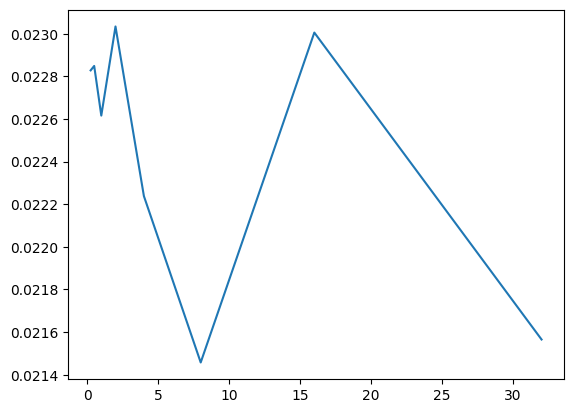

In [92]:
rng = np.random.default_rng(30)

print('For a =', 2)
proba = []
sigma2 = [0.25, 0.5, 1, 2, 4, 8, 16, 32]
for sig2 in sigma2:
    p = importance_sampling(2, sig2, 10000, rng)
    print('For sigma^2 =', sig2, ', the probability is', p)
    proba.append(p)
plt.plot(sigma2, proba)

Part 8

In [93]:
def importance_sampling_exp(n, lbd, rng):

    Y = rng.exponential(scale=1/lbd, size=n)

    weights = (np.exp((1 + lbd) * Y) / lbd) * ((Y >= 0) & (Y <= 1))

    return np.mean(weights)

For lambda = 0.25 , we estimate the integral as 1.6676068119620133
For lambda = 0.5 , we estimate the integral as 1.7282926903931126
For lambda = 0.75 , we estimate the integral as 1.7477651534678496
For lambda = 1 , we estimate the integral as 1.7621614766052789
For lambda = 1.25 , we estimate the integral as 1.7028044513350007
For lambda = 1.5 , we estimate the integral as 1.7049124793141295
For lambda = 1.75 , we estimate the integral as 1.6823565407177998
For lambda = 2 , we estimate the integral as 1.7293659974409668
For lambda = 3 , we estimate the integral as 1.7185037208531466
For lambda = 4 , we estimate the integral as 1.7038532000487006
For lambda = 5 , we estimate the integral as 1.7590076377044723
For lambda = 6 , we estimate the integral as 1.8330271332909598
For lambda = 7 , we estimate the integral as 1.7994645468988937
For lambda = 8 , we estimate the integral as 1.7018031349467564


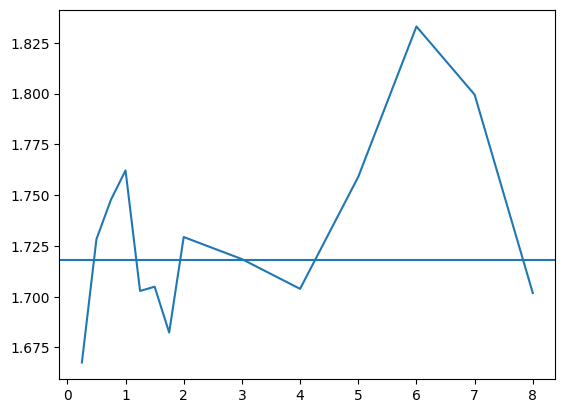

In [94]:
rng = np.random.default_rng(30)

lambdas = [0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 3, 4, 5, 6, 7, 8]
integrals = []
for lbd in lambdas:
    integral = importance_sampling_exp(10000, lbd, rng)
    integrals.append(integral)
    print("For lambda =", lbd, ", we estimate the integral as", integral)

plt.plot(lambdas, integrals)
true_value = np.e - 1
plt.axhline(true_value)

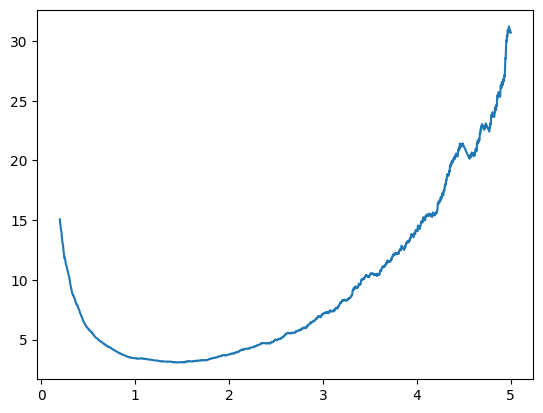

In [95]:
def variance_check(n, lambdas):
    
    variances = []

    for lbd in lambdas:
        rng = np.random.default_rng(30)
        Y = rng.exponential(1/lbd, n)

        W = (np.exp((1 + lbd) * Y) / lbd) * ((Y >= 0) & (Y <= 1))
        var= np.var(W)

        variances.append(var)

    return variances

n = 10000
lambdas = np.linspace(0.2, 5, 2000)
variances = variance_check(n, lambdas)

plt.plot(lambdas, variances)

Part 9